In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mudata as md
import glob

In [2]:
data_dir = "/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/"
results_files = glob.glob(f"{data_dir}/GSE120861_at_scale_screen_chunk.*.results.csv.gz")
results_files

['/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/GSE120861_at_scale_screen_chunk.00.results.csv.gz',
 '/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/GSE120861_at_scale_screen_chunk.01.results.csv.gz',
 '/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/GSE120861_at_scale_screen_chunk.04.results.csv.gz',
 '/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/GSE120861_at_scale_screen_chunk.03.results.csv.gz',
 '/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/GSE120861_at_scale_screen_chunk.02.results.csv.gz',
 '/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/GSE120861_at_scale_screen_chunk.06.results.csv.gz',
 '/data/pinello/SHARED_DATA/gasperini_2019/gasperini_atscale/GSE120861_at_scale_screen_chunk.05.results.csv.gz']

In [3]:
scpower_df = pd.concat(pd.read_csv(f, index_col=0) for f in results_files).reset_index(drop=True)
scpower_df

,element,gene,z_value,p_value
0,ACTB_TSS,RP11-34P13.7,-0.208541,0.834806
1,ACTG1_TSS,RP11-34P13.7,-0.182796,0.854958
2,ACYP1_TSS,RP11-34P13.7,0.112196,0.910668
3,ADIPOR1_TSS,RP11-34P13.7,1.185820,0.235694
4,ALDH1A2_TSS,RP11-34P13.7,0.044827,0.964245
...,...,...,...,...
86691117,scrambled_5,ADCK4,-0.362690,0.716836
86691118,scrambled_6,ADCK4,-0.199261,0.842059
86691119,scrambled_7,ADCK4,0.504334,0.614027
86691120,scrambled_8,ADCK4,0.047674,0.961976


In [4]:
mdata = md.read_h5mu(f"{data_dir}/GSE120861_at_scale_screen.h5mu")
mdata

MuData object with n_obs × n_vars = 207324 × 26324
  2 modalities
    rna:	207324 x 13135
      obs:	'sample', 'total_umis', 'Size_Factor', 'read_count', 'umi_count', 'proportion', 'guide_count', 'id', 'prep_batch', 'within_batch_chip', 'within_chip_lane', 'percent.mito'
      var:	'gene_name', 'contig', 'start', 'end'
    grna:	207324 x 13189
      var:	'Spacer', 'Target_Site', 'chr.candidate_enhancer', 'start.candidate_enhancer', 'stop.candidate_enhancer', 'Category', 'element'
      uns:	'elements'
      varm:	'element_targeted'

In [ ]:
%%time
from scipy.sparse import dok_matrix
mdata['rna'].var=mdata['rna'].var.assign(chr=lambda x: ['chr'+c for c in x['contig']])


In [285]:
guide_targets = mdata['grna'].var.assign(gene_name = lambda x: x['Target_Site']).merge(mdata['rna'].var, how='left')
guide_targets = guide_targets.assign(
    chr = lambda df: df.apply(lambda row: row['chr.candidate_enhancer'] if pd.isna(row['chr']) else row['chr'], axis=1),
    start = lambda df: df.apply(lambda row: row['start.candidate_enhancer'] if pd.isna(row['start']) else row['start'], axis=1),
    end = lambda df: df.apply(lambda row: row['stop.candidate_enhancer'] if pd.isna(row['end']) else row['end'], axis=1)
)

In [289]:
guide_targets

,Spacer,Target_Site,chr.candidate_enhancer,start.candidate_enhancer,stop.candidate_enhancer,Category,element,gene_name,contig,start,end,chr
0,AATGAGGAGCAAACGAAAAT,control,NaN,NaN,NaN,NTC,scrambled_20,control,NaN,NaN,NaN,NaN
1,ACGAAATGTTTCATGACCAA,control,NaN,NaN,NaN,NTC,scrambled_23,control,NaN,NaN,NaN,NaN
2,ATAGATTTACGTTACTCTCT,control,NaN,NaN,NaN,NTC,scrambled_25,control,NaN,NaN,NaN,NaN
3,ATTAGCATCAGGTAGACTAA,control,NaN,NaN,NaN,NTC,scrambled_18,control,NaN,NaN,NaN,NaN
4,CCATAAAGAATTCGGTGTAG,control,NaN,NaN,NaN,NTC,scrambled_16,control,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
13184,TCGGTGCGCGCCTGTCCGG,ZNF593,NaN,NaN,NaN,TSS,ZNF593_TSS,ZNF593,1,26496362.0,26498551.0,chr1
13185,AGAGTGCGGGCGGAAGACG,ZNHIT1,NaN,NaN,NaN,TSS,ZNHIT1_TSS,ZNHIT1,7,100860949.0,100867471.0,chr7
13186,AGTTGTGTTGTGCCAATGG,ZNHIT1,NaN,NaN,NaN,TSS,ZNHIT1_TSS,ZNHIT1,7,100860949.0,100867471.0,chr7
13187,CCCGCAGCTATGTCTTCAC,ZRANB2,NaN,NaN,NaN,TSS,ZRANB2_TSS,ZRANB2,1,71528974.0,71546980.0,chr1


In [318]:
%%time
a=mdata['rna'].var['chr']
b=guide_targets['chr']
chr_match = np.zeros((len(a), len(b)))          
for i, chr1 in enumerate(a):
    for j, chr2 in enumerate(b):
        if chr1==chr2:
            chr_match[i,j]=1

CPU times: user 30.9 s, sys: 207 ms, total: 31.1 s
Wall time: 31.1 s


In [320]:
chr_match.sum()

9098640.0

In [203]:
from scipy.spatial.distance import cdist

In [374]:
%%time
dists = cdist(
    mdata['rna'].var['start'].values[:, np.newaxis], 
    guide_targets['start'].astype(float).values[:, np.newaxis],
    "cityblock"
)
dists

CPU times: user 238 ms, sys: 255 ms, total: 493 ms
Wall time: 492 ms


array([[           nan,            nan,            nan, ...,
        1.00771654e+08, 7.14396790e+07, 7.14396790e+07],
       [           nan,            nan,            nan, ...,
        1.00726048e+08, 7.13940730e+07, 7.13940730e+07],
       [           nan,            nan,            nan, ...,
        1.00633334e+08, 7.13013590e+07, 7.13013590e+07],
       ...,
       [           nan,            nan,            nan, ...,
        1.00807118e+08, 7.14751430e+07, 7.14751430e+07],
       [           nan,            nan,            nan, ...,
        1.00822157e+08, 7.14901820e+07, 7.14901820e+07],
       [           nan,            nan,            nan, ...,
        1.00824672e+08, 7.14926970e+07, 7.14926970e+07]])

In [402]:
max_dist=1e7
min_dist=1e3
inv_dists=1/(min_dist+dists)
inv_dists[dists>max_dist] = 0
inv_dists

array([[nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       ...,
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.]])

In [403]:
dists

array([[           nan,            nan,            nan, ...,
        1.00771654e+08, 7.14396790e+07, 7.14396790e+07],
       [           nan,            nan,            nan, ...,
        1.00726048e+08, 7.13940730e+07, 7.13940730e+07],
       [           nan,            nan,            nan, ...,
        1.00633334e+08, 7.13013590e+07, 7.13013590e+07],
       ...,
       [           nan,            nan,            nan, ...,
        1.00807118e+08, 7.14751430e+07, 7.14751430e+07],
       [           nan,            nan,            nan, ...,
        1.00822157e+08, 7.14901820e+07, 7.14901820e+07],
       [           nan,            nan,            nan, ...,
        1.00824672e+08, 7.14926970e+07, 7.14926970e+07]])

In [404]:
assert dists.shape == chr_match.shape

In [405]:
dist_chr = np.nan_to_num(chr_match * inv_dists)
dist_chr

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [406]:
np.sum(dist_chr)

2.6777285582047647

In [407]:
(mdata['rna'].X).sum(axis=1).A1
mdata['rna'].obs

,sample,total_umis,Size_Factor,read_count,umi_count,proportion,guide_count,id,prep_batch,within_batch_chip,within_chip_lane,percent.mito,expressed_genes
cell,,,,,,,,,,,,,
AAACCTGAGAGGTACC-1_1A_1_SI-GA-E2,1A_1_SI-GA-E2,17572.0,1.009682,14135.0,964.0,0.969819,67.0,1A_1,prep_batch_1,within_batch_chip_A,within_chip_lane_1,0.058787,3549
AAACCTGAGTCAATAG-1_1A_1_SI-GA-E2,1A_1_SI-GA-E2,8923.0,0.939677,4329.0,293.0,0.844380,26.0,1A_1,prep_batch_1,within_batch_chip_A,within_chip_lane_1,0.036087,2543
AAACCTGCAAACAACA-1_1A_1_SI-GA-E2,1A_1_SI-GA-E2,14637.0,0.990803,12362.0,884.0,0.950538,61.0,1A_1,prep_batch_1,within_batch_chip_A,within_chip_lane_1,0.069823,3191
AAACCTGCACTTCTGC-1_1A_1_SI-GA-E2,1A_1_SI-GA-E2,22798.0,1.036578,7459.0,544.0,0.939551,39.0,1A_1,prep_batch_1,within_batch_chip_A,within_chip_lane_1,0.026187,4539
AAACCTGCATGTAGTC-1_1A_1_SI-GA-E2,1A_1_SI-GA-E2,10136.0,0.952844,14831.0,1054.0,0.959927,37.0,1A_1,prep_batch_1,within_batch_chip_A,within_chip_lane_1,0.007991,2605
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTACCTACA-1_2B_8_SI-GA-H9,2B_8_SI-GA-H9,17938.0,1.011811,4570.0,394.0,0.856522,31.0,2B_8,prep_batch_2,within_batch_chip_B,within_chip_lane_8,0.060598,3451
TTTGTCAGTATCACCA-1_2B_8_SI-GA-H9,2B_8_SI-GA-H9,16543.0,1.003448,4311.0,387.0,0.861915,33.0,2B_8,prep_batch_2,within_batch_chip_B,within_chip_lane_8,0.057789,3693
TTTGTCAGTTCAGACT-1_2B_8_SI-GA-H9,2B_8_SI-GA-H9,15009.0,0.993396,669.0,57.0,0.876923,3.0,2B_8,prep_batch_2,within_batch_chip_B,within_chip_lane_8,0.049037,3162


<AxesSubplot: >

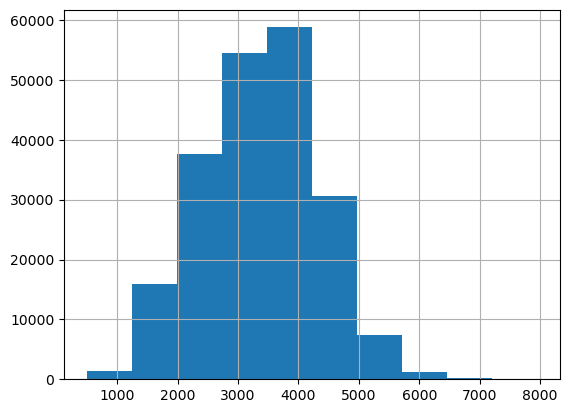

In [6]:
mdata['rna'].obs=mdata['rna'].obs.assign(expressed_genes=(mdata['rna'].X>0).sum(axis=1).A1)
mdata['rna'].obs['expressed_genes'].hist()

(<matplotlib.collections.PathCollection at 0x7f705c3024f0>,)

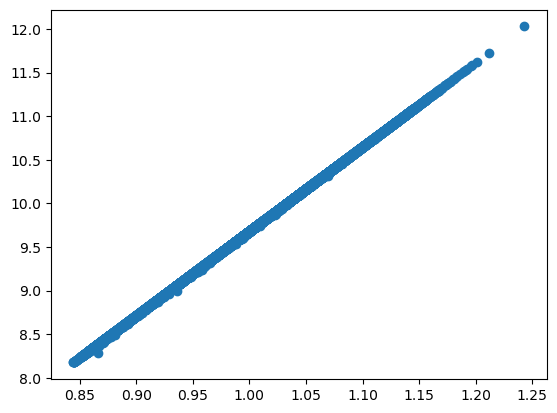

In [7]:
plt.scatter(mdata['rna'].obs['Size_Factor'], np.log(mdata['rna'].X.sum(axis=1).A1)), 
# plt.plot(mdata['rna'].obs['log1p_gene_count'])

In [8]:
sceptre_results = pd.read_csv(f"{data_dir}/sceptre_results_export.csv")
sceptre_results
sceptre_results=sceptre_results.assign(
    gene=mdata['rna'].var.loc[sceptre_results['gene_id']]['gene_name'].values,
).rename(columns={'p_value':'p_value_sceptre', 'gRNA_id':'element'})

sceptre_results

,gene_id,element,p_value_sceptre,skew_t_fit_success,xi,omega,alpha,nu,gene
0,ENSG00000008256,ACTB_TSS,1.684303e-01,True,-0.066602,0.947855,0.126446,3.946003e+01,CYTH3
1,ENSG00000011275,ACTB_TSS,2.010234e-01,True,-0.553322,1.085214,0.737834,8.256523e+01,RNF216
2,ENSG00000075618,ACTB_TSS,9.916670e-01,True,-0.916371,1.312246,0.889398,1.107978e+03,FSCN1
3,ENSG00000075624,ACTB_TSS,5.007100e-11,True,-0.866612,1.783860,0.968370,9.667537e+04,ACTB
4,ENSG00000086232,ACTB_TSS,2.941922e-01,True,0.527563,0.990631,-0.329564,1.791409e+01,EIF2AK1
...,...,...,...,...,...,...,...,...,...
629510,ENSG00000066827,chr8.3446_top_two,1.372567e-01,True,-0.654953,1.099360,1.043521,5.741392e+00,ZFAT
629511,ENSG00000131773,chr8.3446_top_two,1.267156e-01,True,-1.078687,1.427121,3.831266,1.427994e+07,KHDRBS3
629512,ENSG00000022567,chr8.3533_top_two,4.683269e-01,True,-0.159764,0.940689,0.175429,2.627980e+01,SLC45A4
629513,ENSG00000104472,chr8.3533_top_two,1.477046e-01,False,NaN,NaN,NaN,NaN,CHRAC1


In [9]:
mdata['grna'].var.query('element=="random_23"')

,Spacer,Target_Site,chr.candidate_enhancer,start.candidate_enhancer,stop.candidate_enhancer,Category,element
guide,,,,,,,
GCCTTGTTTCTATTTGTAGA,GCCTTGTTTCTATTTGTAGA,originalIDTorder:7,NaN,NaN,NaN,NTC,random_23
ATTGGTATCCGTATAAGCAG,ATTGGTATCCGTATAAGCAG,randomregion,NaN,NaN,NaN,NTC,random_23


In [10]:
# get the true target info
target_pair_df = mdata['grna'].var.groupby('element')['Target_Site'].first().to_frame()
# target_pair_df = mdata['grna'].var.query('Category=="TSS"').value_counts(['element', 'Target_Site']).reset_index().set_index('element')
target_pair_df

,Target_Site
element,
ACTB_TSS,ACTB
ACTG1_TSS,ACTG1
ACYP1_TSS,ACYP1
ADIPOR1_TSS,ADIPOR1
ALDH1A2_TSS,ALDH1A2
...,...
scrambled_21,control
scrambled_22,control
scrambled_23,control


In [11]:
sceptre_results

,gene_id,element,p_value_sceptre,skew_t_fit_success,xi,omega,alpha,nu,gene
0,ENSG00000008256,ACTB_TSS,1.684303e-01,True,-0.066602,0.947855,0.126446,3.946003e+01,CYTH3
1,ENSG00000011275,ACTB_TSS,2.010234e-01,True,-0.553322,1.085214,0.737834,8.256523e+01,RNF216
2,ENSG00000075618,ACTB_TSS,9.916670e-01,True,-0.916371,1.312246,0.889398,1.107978e+03,FSCN1
3,ENSG00000075624,ACTB_TSS,5.007100e-11,True,-0.866612,1.783860,0.968370,9.667537e+04,ACTB
4,ENSG00000086232,ACTB_TSS,2.941922e-01,True,0.527563,0.990631,-0.329564,1.791409e+01,EIF2AK1
...,...,...,...,...,...,...,...,...,...
629510,ENSG00000066827,chr8.3446_top_two,1.372567e-01,True,-0.654953,1.099360,1.043521,5.741392e+00,ZFAT
629511,ENSG00000131773,chr8.3446_top_two,1.267156e-01,True,-1.078687,1.427121,3.831266,1.427994e+07,KHDRBS3
629512,ENSG00000022567,chr8.3533_top_two,4.683269e-01,True,-0.159764,0.940689,0.175429,2.627980e+01,SLC45A4
629513,ENSG00000104472,chr8.3533_top_two,1.477046e-01,False,NaN,NaN,NaN,NaN,CHRAC1


In [12]:
# subset down to tss guides
merge_df = target_pair_df.merge(scpower_df, on='element', how='right').merge(sceptre_results, on=['element','gene'], how='inner')
# merge_df
merge_df = merge_df.sort_values('p_value', ascending=True)
merge_df

,element,Target_Site,gene,z_value,p_value,gene_id,p_value_sceptre,skew_t_fit_success,xi,omega,alpha,nu
472804,VDAC3_TSS,VDAC3,VDAC3,-3.620113e+01,5.844706e-287,ENSG00000078668,0.000000e+00,True,-0.872836,1.160325,0.740862,4.263754e+03
524223,COX4I1_TSS,COX4I1,COX4I1,-3.337506e+01,3.154847e-244,ENSG00000131143,0.000000e+00,True,-0.530113,0.917839,0.886454,1.204569e+05
436901,GNB2_TSS,GNB2,GNB2,-3.105825e+01,8.826540e-212,ENSG00000172354,0.000000e+00,True,-0.951113,1.204579,1.148613,9.541792e+05
512817,ST13_TSS,ST13,ST13,-3.025946e+01,3.916967e-201,ENSG00000100380,0.000000e+00,True,0.187057,0.920118,0.058751,7.062606e+01
250571,FAM96A_TSS,FAM96A,FAM96A,-3.017995e+01,4.342299e-200,ENSG00000166797,1.526018e-11,True,-0.520518,1.002152,0.868219,2.308900e+01
...,...,...,...,...,...,...,...,...,...,...,...,...
539974,scrambled_11,non-targeting,MYO18A,-4.795962e-06,9.999962e-01,ENSG00000196535,6.483515e-01,True,-0.860048,1.271175,1.214620,8.507573e+06
320451,scrambled_3,non-targeting,PIP4K2A,3.966245e-06,9.999968e-01,ENSG00000150867,1.612591e-01,True,0.740608,1.234810,-1.067627,9.825089e+06
442242,random_16,randomregion,TSPAN33,2.918915e-06,9.999977e-01,ENSG00000158457,3.818613e-01,True,-1.028043,1.465084,2.458747,1.812228e+05
246456,scrambled_13,non-targeting,CCNDBP1,8.485366e-07,9.999993e-01,ENSG00000166946,2.641037e-01,True,0.915078,1.264951,-1.082970,2.132743e+07


In [13]:
merge_df=merge_df.assign(is_target=lambda x: x['Target_Site']==x['gene'])
# merge_df=merge_df.assign(is_target=lambda x: x['Target_Site']==x['gene'])


In [14]:
target_genes = mdata['grna'].var.query('Category=="TSS"')['Target_Site'].unique()
ntc_gene_labels=mdata['grna'].var.query('Category=="NTC"')['Target_Site'].unique()
ntc_gene_labels

['control', 'cag_promoter', 'non-targeting', 'originalIDTorder:1', 'originalIDTorder:2', ..., 'originalIDTorder:6', 'originalIDTorder:7', 'originalIDTorder:8', 'originalIDTorder:9', 'randomregion']
Length: 12
Categories (6182, object): ['2018-09-11 00:00:00', 'ACTB', 'ACTG1', 'ACYP1', ..., 'pos_control_Klannchr_HS1', 'pos_control_mosaic_HB_HBE1_tss_A', 'pos_control_mosaic_HB_HBE1_tss_B', 'randomregion']

## Visualize hits



<AxesSubplot: xlabel='z_value', ylabel='Density'>

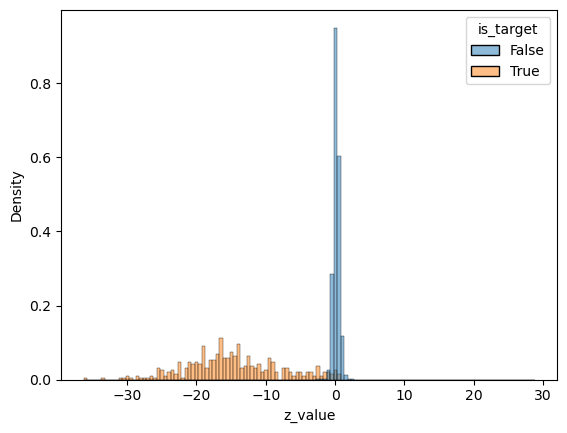

In [132]:
sns.histplot(merge_df, x='z_value', hue='is_target', common_norm=False, stat="density", binwidth=0.5)
# from sklearn.linear_model import LinearRegression

# reg_x=(merge_df[["z_value"]].values)
# reg_y=(merge_df[["SCEPTRE_z_value"]].values)
# reg = LinearRegression(fit_intercept=False).fit(reg_x, reg_y)
# print("slope:", reg.coef_[0,0])
# print("R^2:", reg.score(reg_x, reg_y))


In [16]:
# element_counts = (mdata['grna'].X @ mdata['grna'].varm['element_targeted']).sum(axis=0)
# plt.hist(element_counts)
# plt.xlim(0,None)

# element_count_df = pd.DataFrame({'element':mdata['grna'].uns['elements'], 'cells':element_counts})


In [17]:
# # mdata['rna'].var.assign(mean_expr = mdata['rna'].X.mean(axis=0))
# mdata['rna'].var=mdata['rna'].var.assign(log10_mean_expression=np.log10(empirical_gene_mean))
# plt.hist(mdata['rna'].var['log10_mean_expression'])

In [18]:
# frac_expressed = (mdata['rna'].X>0).mean(axis=0).A1
# mdata['rna'].var=mdata['rna'].var.assign(frac_expressed=frac_expressed)
# plt.hist(frac_expressed)

In [19]:
# pd.read_excel(f"{data_dir}/mmc2.xlsx", sheet_name=2)
# sns.scatterplot(merge_df, x='SCEPTRE_z_value', y='SCEPTRE_p_value', hue='pair_type', alpha=0.3)

In [20]:
# plt.title("z-value comparison")
# sns.scatterplot(merge_df, x='z_value', y='SCEPTRE_z_value', hue='pair_type', alpha=0.3, palette='Set1')
# plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
# plt.show()


## Interactive data visualization
Need to subset and clip the data so that we can plot interactively

In [21]:
# min_p_value = 1e-20
# merge_df['p_value'] = np.maximum(merge_df['p_value'], min_p_value)

# sns.scatterplot(merge_df, x="p_value", y="SCEPTRE_p_value", hue="pair_type", alpha=0.3, palette="Set1")
# # plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
# plt.axhline(1e-4, c='black', linestyle='dashed')
# plt.axvline(1e-4,  c='black', linestyle='dashed')

# plt.loglog()
# # plt.legend()
# plt.xlim(1e-21, 2)
# plt.ylim(1e-21, 2)
# plt.hist(mdata['rna'][:,mdata['rna'].var["gene_name"]=="SPR"].X.todense())
# plt.xlim(1e-21neg_controls, 2)
# neg_controls

In [22]:
neg_controls = merge_df[merge_df['Target_Site'].isin(ntc_gene_labels)]
neg_controls = neg_controls.sort_values('p_value').assign(
    quantile = lambda x: np.linspace(0,1, num=len(x))
)

neg_controls = neg_controls.sort_values('p_value_sceptre').assign(
    quantile_sceptre = lambda x: np.linspace(0,1, num=len(x))
)
neg_controls.query("p_value<0.05")

,element,Target_Site,gene,z_value,p_value,gene_id,p_value_sceptre,skew_t_fit_success,xi,omega,alpha,nu,is_target,quantile,quantile_sceptre
65702,random_17,randomregion,FAM89A,-4.399768,0.000011,ENSG00000182118,4.430695e-11,True,-0.576669,1.220119,0.584505,3.293256e+01,False,0.000002,0.000000
497325,scrambled_2,non-targeting,LENG1,-2.029663,0.042391,ENSG00000105617,6.492033e-07,True,0.056033,0.916635,-0.245335,4.543342e+01,False,0.000369,0.000004
575765,random_16,randomregion,MALT1,-2.367964,0.017886,ENSG00000172175,7.590893e-06,True,-0.731101,1.297401,1.206938,8.143889e+06,False,0.000117,0.000017
23784,scrambled_10,non-targeting,CCDC24,-2.474829,0.013330,ENSG00000159214,2.017040e-05,True,-0.654092,1.151998,1.003416,2.571078e+05,False,0.000085,0.000028
83242,scrambled_17,control,SPR,-2.992501,0.002767,ENSG00000116096,2.559952e-05,True,0.321528,1.023391,-0.624738,1.833113e+01,False,0.000024,0.000032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550335,scrambled_1,non-targeting,CRHR1,2.258750,0.023899,ENSG00000120088,1.000000e+00,False,NaN,NaN,NaN,NaN,False,0.000165,0.999952
35959,random_18,originalIDTorder:1,STRIP1,2.190520,0.028487,ENSG00000143093,1.000000e+00,False,NaN,NaN,NaN,NaN,False,0.000202,0.999967
32306,scrambled_13,non-targeting,CDC7,2.085956,0.036983,ENSG00000097046,1.000000e+00,False,NaN,NaN,NaN,NaN,False,0.000304,0.999970
70425,scrambled_10,non-targeting,TAF1B,2.088095,0.036789,ENSG00000115750,1.000000e+00,False,NaN,NaN,NaN,NaN,False,0.000301,0.999974


In [23]:
worst_offenders = neg_controls.query("p_value<0.05")['gene'].unique()
len(worst_offenders)
# mdata['rna'][:, mdata['rna'].var['gene_name'].isin(worst_offenders).values].var
# mdata['rna'].var['gene_name'].isin(worst_offenders).index

247

In [24]:
# element_count_df.merge(neg_controls, on="element").sort_values('p_value').head(50)
# neg_controls
# (mdata['grna'].var['element']=='random_17').values
# sns.histplot(guide_counts)
# plt.semilogy()

(1, 1.8555733072068612e-06)

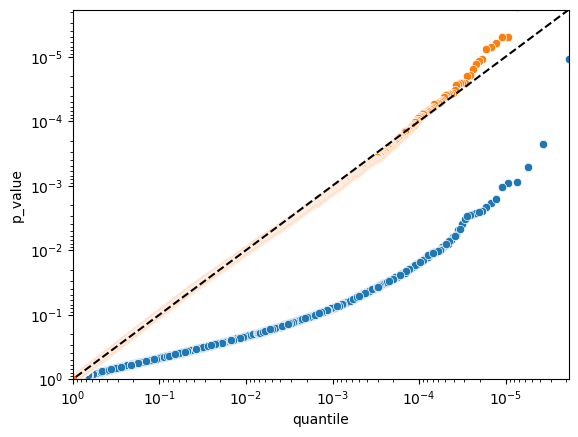

In [25]:
plt.axline((0,0), slope=1, linestyle="dashed", color="black")
# plt.scatter(np.linspace(0,1, num=len(neg_controls)), neg_controls['p_value'].sort_values())
sns.scatterplot(neg_controls, x="quantile", y='p_value')
sns.scatterplot(neg_controls, x="quantile_sceptre", y='p_value_sceptre')
plt.loglog()
plt.ylim(1,1/len(neg_controls))
plt.xlim(1,1/len(neg_controls))

In [26]:
# pos_controls.groupby('is_target')['p_value_sceptre'].rank(pct=True).min()
# pos_controls['element'].str.contains('TSS').all()

In [27]:
pos_controls = merge_df[merge_df['Target_Site'].isin(target_genes)]
pos_controls = pos_controls.assign(
    quantile=lambda x: x.groupby('is_target')['p_value'].rank(pct=True),
    quantile_sceptre=lambda x: x.groupby('is_target')['p_value_sceptre'].rank(pct=True, method="first"),
)

# pos_controls = neg_controls.sort_values('p_value_sceptre').assign(
    # quantile_sceptre = lambda x: np.linspace(0,1, num=len(x))
# )


# pos_controls=pos_controls[~pos_controls['gene'].str.contains("-AS")] # remove alt start sites
pos_controls=pos_controls.assign(
    perturbo_rank=lambda x: x.groupby('element')['z_value'].rank(),
    perturbo_p_rank=lambda x: x.groupby('element')['p_value'].rank(),
    SCEPTRE_p_rank=lambda x: x.groupby('element')['p_value_sceptre'].rank(),
    # SCEPTRE_z_rank=lambda x: x.groupby('guide')['SCEPTRE_z_value'].rank()
)
pos_controls

,element,Target_Site,gene,z_value,p_value,gene_id,p_value_sceptre,skew_t_fit_success,xi,omega,alpha,nu,is_target,quantile,quantile_sceptre,perturbo_rank,perturbo_p_rank,SCEPTRE_p_rank
472804,VDAC3_TSS,VDAC3,VDAC3,-36.201126,5.844706e-287,ENSG00000078668,0.000000e+00,True,-0.872836,1.160325,0.740862,4.263754e+03,True,0.002646,0.002646,1.0,1.0,1.0
524223,COX4I1_TSS,COX4I1,COX4I1,-33.375060,3.154847e-244,ENSG00000131143,0.000000e+00,True,-0.530113,0.917839,0.886454,1.204569e+05,True,0.005291,0.005291,1.0,1.0,1.0
436901,GNB2_TSS,GNB2,GNB2,-31.058254,8.826540e-212,ENSG00000172354,0.000000e+00,True,-0.951113,1.204579,1.148613,9.541792e+05,True,0.007937,0.007937,1.0,1.0,1.0
512817,ST13_TSS,ST13,ST13,-30.259464,3.916967e-201,ENSG00000100380,0.000000e+00,True,0.187057,0.920118,0.058751,7.062606e+01,True,0.010582,0.010582,1.0,1.0,1.0
250571,FAM96A_TSS,FAM96A,FAM96A,-30.179945,4.342299e-200,ENSG00000166797,1.526018e-11,True,-0.520518,1.002152,0.868219,2.308900e+01,True,0.013228,0.820106,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50528,UFC1_TSS,UFC1,CD84,0.000419,9.996657e-01,ENSG00000066294,2.441914e-01,True,-0.757852,1.285753,1.304018,3.330828e+01,False,0.999317,0.274979,11.0,24.0,7.0
131610,GATA2_TSS,GATA2,PODXL2,-0.000390,9.996892e-01,ENSG00000114631,3.167538e-01,True,-0.531587,0.978537,0.390773,6.530531e+06,False,0.999488,0.342955,7.0,19.0,7.0
479405,AZIN1_TSS,AZIN1,UBR5,-0.000300,9.997605e-01,ENSG00000104517,3.458723e-01,True,0.506477,1.136398,-0.687359,1.381978e+03,False,0.999658,0.371307,6.0,8.0,6.0
318603,NUDT5_TSS,NUDT5,MCM10,-0.000283,9.997745e-01,ENSG00000065328,5.673601e-01,True,-0.574310,1.105319,0.568688,2.217039e+01,False,0.999829,0.576430,5.0,10.0,8.0


(1, 0.00016043638697256537)

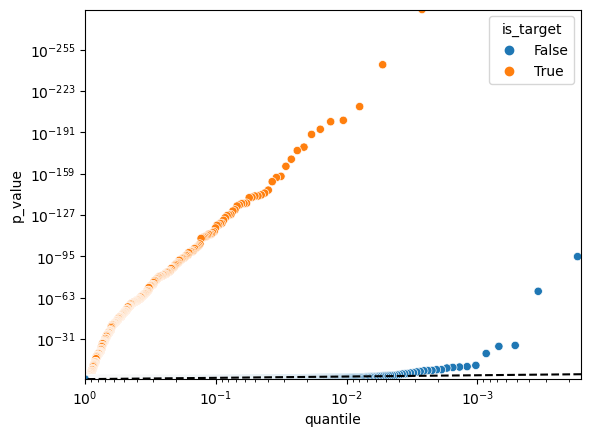

In [28]:
plt.axline((0,0), slope=1, linestyle="dashed", color="black")
sns.scatterplot(pos_controls, x="quantile", y='p_value', hue="is_target")
plt.loglog()
plt.ylim(1,pos_controls['p_value'].min())
plt.xlim(1,1/len(pos_controls))

(1, 0.00016043638697256537)

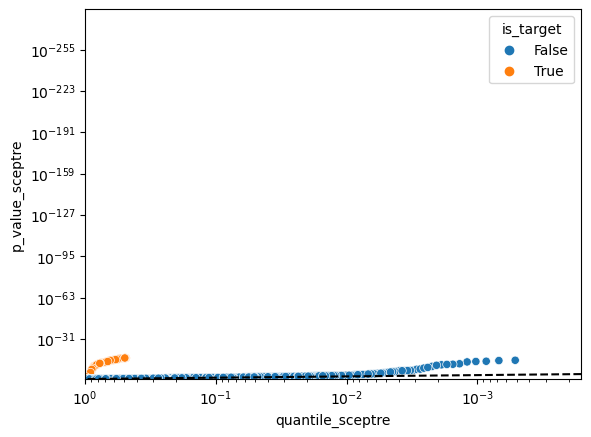

In [29]:
plt.axline((0,0), slope=1, linestyle="dashed", color="black")
sns.scatterplot(pos_controls, x="quantile_sceptre", y='p_value_sceptre', hue="is_target")
plt.loglog()
plt.ylim(1,pos_controls['p_value'].min())
plt.xlim(1,1/len(pos_controls))

In [30]:
target_pairs = pos_controls.query('is_target')
print("our accuracy: "+str(len(target_pairs.query('perturbo_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_p_rank==1'))/len(target_pairs)))
# print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_p_rank==1'))/len(target_pairs)))

our accuracy: 0.9814814814814815
SCEPTRE accuracy: 0.9629629629629629


In [31]:
target_pairs.query('SCEPTRE_p_rank>1 and perturbo_rank==1')

,element,Target_Site,gene,z_value,p_value,gene_id,p_value_sceptre,skew_t_fit_success,xi,omega,alpha,nu,is_target,quantile,quantile_sceptre,perturbo_rank,perturbo_p_rank,SCEPTRE_p_rank
171173,TBCA_TSS,TBCA,TBCA,-29.419480,3.094724e-190,ENSG00000171530,1.996008e-03,False,NaN,NaN,NaN,NaN,True,0.018519,0.923280,1.0,1.0,2.0
36626,ATP5F1_TSS,ATP5F1,ATP5F1,-24.341246,7.177097e-131,ENSG00000116459,3.286196e-10,True,-0.179367,0.888180,0.063502,36.585936,True,0.074074,0.862434,1.0,1.0,2.0
520147,TTC3_TSS,TTC3,TTC3,-20.457832,5.116251e-93,ENSG00000182670,5.423439e-14,True,-0.646047,1.112483,0.966592,497381.143149,True,0.185185,0.690476,1.0,1.0,2.0
28010,TMEM59_TSS,TMEM59,TMEM59,-16.942924,2.170612e-64,ENSG00000116209,1.996008e-03,False,NaN,NaN,NaN,NaN,True,0.370370,0.939153,1.0,1.0,2.0
167189,DHX29_TSS,DHX29,DHX29,-16.621712,4.852683e-62,ENSG00000067248,1.996008e-03,False,NaN,NaN,NaN,NaN,True,0.394180,0.941799,1.0,1.0,2.0
628792,FBL_TSS,FBL,FBL,-14.168158,1.442348e-45,ENSG00000105202,1.996008e-03,False,NaN,NaN,NaN,NaN,True,0.571429,0.947090,1.0,1.0,2.0
90451,ZC3H8_TSS,ZC3H8,ZC3H8,-12.694238,6.364644e-37,ENSG00000144161,3.480277e-11,True,-0.526701,1.093070,0.841101,37.816163,True,0.653439,0.828042,1.0,1.0,2.0
529875,PSMB6_TSS,PSMB6,PSMB6,-12.282618,1.123045e-34,ENSG00000142507,1.996008e-03,False,NaN,NaN,NaN,NaN,True,0.679894,0.960317,1.0,1.0,1.5


In [32]:
target_pairs.query('SCEPTRE_p_rank==1 and perturbo_rank>1')

,element,Target_Site,gene,z_value,p_value,gene_id,p_value_sceptre,skew_t_fit_success,xi,omega,alpha,nu,is_target,quantile,quantile_sceptre,perturbo_rank,perturbo_p_rank,SCEPTRE_p_rank
69661,ID2_TSS,ID2,ID2,-0.170178,0.86487,ENSG00000115738,0.027829,True,-0.764789,2.384055,0.921109,2.932923e+06,True,0.994709,0.981481,2.0,6.0,1.0


(0.0, 20.0)

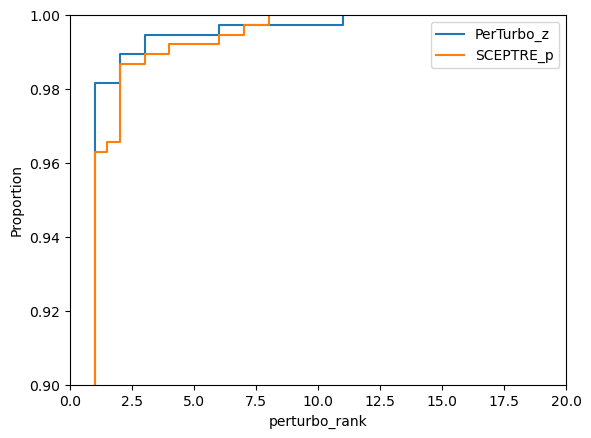

In [33]:
# with plt.rc_context({"figure.figsize": [3,3]}):
# sns.ecdfplot(pos_controls.query('is_target'), x='perturbo_p_rank',stat="proportion", label="PerTurbo")
sns.ecdfplot(pos_controls.query('is_target'), x='perturbo_rank',stat="proportion", label="PerTurbo_z")
# with plt.rc_context({"figure.figsize": [3,3]}):
sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_p_rank',stat="proportion", label="SCEPTRE_p")
plt.legend()
plt.ylim(0.9, 1)
plt.xlim([0,20])
plt.ylim(0.9, 1)
plt.xlim([0,20])


0.9450897571277719 0.9129511677282376


Text(0.5, 1.0, 'perturbo vs. SCEPTRE p-values')

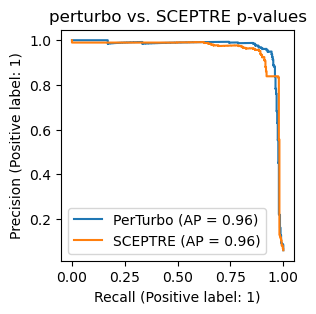

In [124]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve, f1_score, fbeta_score

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(
      pos_controls['is_target'],
      1-pos_controls['z_value'],
      name="PerTurbo", 
  )
  PrecisionRecallDisplay.from_predictions(
      pos_controls['is_target'],
      1-pos_controls['p_value_sceptre'],
      ax=roc.ax_,
      name="SCEPTRE",
    
  )

precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=f1_score(pos_controls['is_target'], pos_controls['z_value']<-2)
score2=f1_score(pos_controls['is_target'], pos_controls['p_value_sceptre']<1e-7)
score1=fbeta_score(pos_controls['is_target'], pos_controls['z_value']<-2, beta=2)
score2=fbeta_score(pos_controls['is_target'], pos_controls['p_value_sceptre']<1e-5, beta=2)

print(score1, score2)
plt.title("perturbo vs. SCEPTRE p-values")
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)

In [83]:
# len(threshold)
# len(precision)
# threshold[:10]
# precision[-10:]
# recall

# threshold[-380]
# precision[-380]
# recall[-380]
2/(1/precision + 1/recall)

# precision

/tmp/ipykernel_244232/1361715548.py:10: RuntimeWarning: divide by zero encountered in divide
  2/(1/precision + 1/recall)


array([0.11435486, 0.11437216, 0.11438947, ..., 0.01052632, 0.00527704,
       0.        ])

In [34]:
mdata['grna'].var.value_counts("Category")
mdata['grna'].var.value_counts("Category")

Category
candidate_enhancer:picked_by_model_built_from_pilot              7706
candidate_enhancer:repeated_from_pilot:top_gRNA_pair             1956
candidate_enhancer:picked_by_exploratory_submodular_selection    1896
TSS                                                               762
candidate_enhancer:repeated_from_pilot:alternative_gRNA_pair      754
NTC                                                               101
Positive_control_to_globin_locus                                   14
dtype: int64